<a href="https://colab.research.google.com/github/Sruthi051006/sruthi-codeboosters-2026/blob/main/Day-5/Student_Analytics_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')#ignores the warnings

print("all libraries imported")
print(f"pandas version: {pd.__version__}")
print(f"sql version: {sqlite3.version}")

df = pd.read_csv('student_performance.csv')

all libraries imported
pandas version: 2.2.2
sql version: 2.6.0


In [ ]:
conn = sqlite3.connect('college.db')
cursor = conn.cursor()
df.to_sql(
    'students',
    conn,
    if_exists='replace',
    index=False
)
cursor.execute("SELECT COUNT(*) FROM STUDENTS")
count = cursor.fetchone()[0]


chart1_sql = """
    SELECT gender, ROUND(AVG(attendance_percentage), 2) AS avg_percentage
    FROM students
    GROUP BY gender
    ORDER BY avg_percentage DESC
"""



In [ ]:
import sqlite3
import pandas as pd

# Connect to the database
conn = sqlite3.connect('college.db')

# List of 5 Analysis Queries
queries = {
    "Top Math Performers per Dept": """
        SELECT Department, MAX(Average_Math_Score) as Highest_Score
        FROM students
        GROUP BY Department
        ORDER BY Highest_Score DESC;""",

    "Department Attendance Ranking": """
        SELECT Department, ROUND(AVG(Average_Attendance), 2) as Avg_Attendance
        FROM students
        GROUP BY Department
        ORDER BY Avg_Attendance DESC;""",

    "Below Average Enrollment Depts": """
        SELECT Department, Student_Count
        FROM students
        WHERE Student_Count < (SELECT AVG(Student_Count) FROM students)
        ORDER BY Student_Count ASC;""",

    "Attendance vs Math Performance": """
        SELECT Department, Average_Attendance, Average_Math_Score
        FROM students
        ORDER BY Average_Attendance DESC;""",

    "College Overview Statistics": """
        SELECT
            COUNT(*) as Total_Departments,
            SUM(Student_Count) as Total_Students,
            ROUND(AVG(Average_Math_Score), 2) as College_Avg_Math,
            ROUND(AVG(Average_Attendance), 2) as College_Avg_Attendance
        FROM students;"""
}

# Execute and print results
for title, query in queries.items():
    print(f"\n--- {title} ---")
    result = pd.read_sql_query(query, conn)
    print(result.to_string(index=False))

# Close connection
conn.close()


--- Top Math Performers per Dept ---
      Department  Highest_Score
    Data Science             88
      Electrical             78
Computer Science             75
           Civil             72
      Mechanical             70

--- Department Attendance Ranking ---
      Department  Avg_Attendance
    Data Science            90.0
           Civil            88.0
Computer Science            85.0
      Electrical            82.0
      Mechanical            78.0

--- Below Average Enrollment Depts ---
Department  Student_Count
     Civil             90
Mechanical            100

--- Attendance vs Math Performance ---
      Department  Average_Attendance  Average_Math_Score
    Data Science                  90                  88
           Civil                  88                  72
Computer Science                  85                  75
      Electrical                  82                  78
      Mechanical                  78                  70

--- College Overview Statistics 

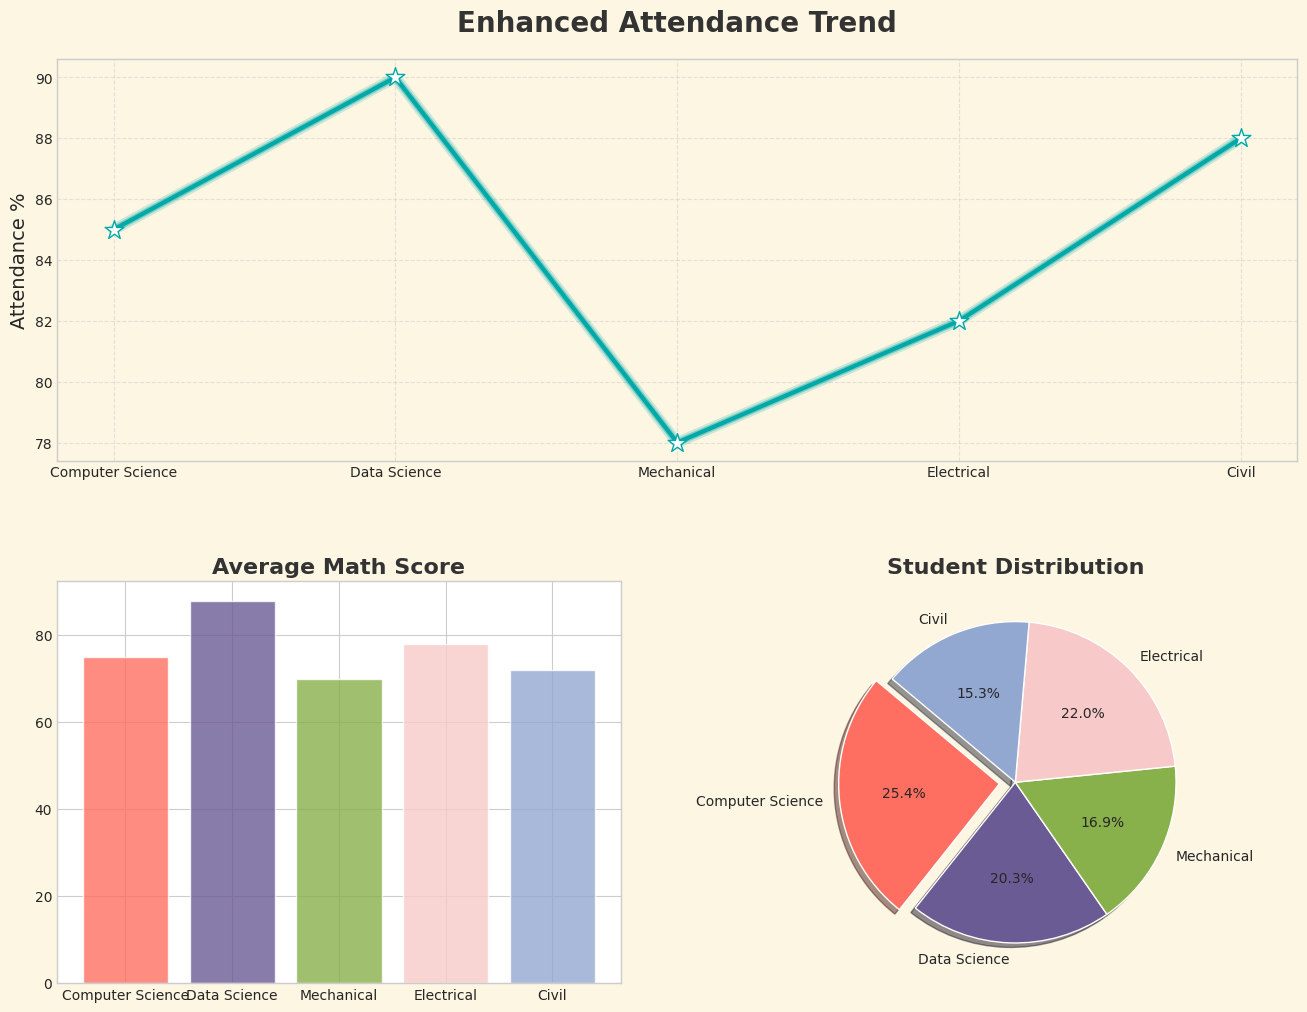

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import numpy as np

# Data
data = {
    'Department': ['Computer Science', 'Data Science', 'Mechanical', 'Electrical', 'Civil'],
    'Average_Attendance': [85, 90, 78, 82, 88],
    'Student_Count': [150, 120, 100, 130, 90],
    'Average_Math_Score': [75, 88, 70, 78, 72]
}
df = pd.DataFrame(data)

# Create figure with GridSpec for -_- layout
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('#fdf6e3')
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], hspace=0.3, wspace=0.2)

# Colors
colors = ['#FF6F61', '#6B5B95', '#88B04B', '#F7CAC9', '#92A8D1']

# 1. Line Chart (Top Row, spanning two columns) - Enhanced Glow Effect
ax_line = fig.add_subplot(gs[0, :])
ax_line.set_facecolor('#fdf6e3')

# Glow effect: Plotting the line multiple times
line_color = '#00a8a8' # Teal/Cyan color
linewidths = [8, 5, 3]
alphas = [0.2, 0.4, 1.0]

for lw, alpha in zip(linewidths, alphas):
    ax_line.plot(df['Department'], df['Average_Attendance'],
                 color=line_color, linewidth=lw, alpha=alpha, solid_capstyle='round')

# Add star markers
ax_line.scatter(df['Department'], df['Average_Attendance'],
                color='white', edgecolors=line_color, s=200, marker='*', zorder=5)

ax_line.set_title('Enhanced Attendance Trend', fontsize=20, fontweight='bold', color='#333333', pad=20)
ax_line.set_ylabel('Attendance %', fontsize=14)
ax_line.grid(True, linestyle='--', alpha=0.5, zorder=0)

# 2. Bar Graph (Bottom Left)
ax_bar = fig.add_subplot(gs[1, 0])
ax_bar.bar(df['Department'], df['Average_Math_Score'], color=colors, alpha=0.8, edgecolor='white')
ax_bar.set_title('Average Math Score', fontsize=16, fontweight='bold', color='#333333')
ax_bar.set_facecolor('#ffffff')

# 3. Pie Chart (Bottom Right)
ax_pie = fig.add_subplot(gs[1, 1])
max_idx = df['Student_Count'].idxmax()
explode = [0.1 if i == max_idx else 0 for i in range(len(df))]

ax_pie.pie(df['Student_Count'], labels=df['Department'], autopct='%1.1f%%',
           colors=colors, startangle=140, explode=explode, shadow=True,
           wedgeprops={'linewidth': 1, 'edgecolor': 'white'})
ax_pie.set_title('Student Distribution', fontsize=16, fontweight='bold', color='#333333')

plt.show()

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# --- FIX: Ensure your DataFrame has these exact columns ---
# If you are loading from your CSV, replace 'student_performance.csv'
# with your actual file if needed, and map your columns.
data = {
    'Math_Score': [75, 88, 70, 78, 72, 85, 92, 65, 80, 77],
    'Attendance': [85, 90, 78, 82, 88, 92, 95, 70, 84, 81],
    'Study_Hours': [5, 7, 3, 4, 3, 6, 8, 2, 5, 4],
    'Programming_Score': [70, 85, 60, 75, 65, 80, 90, 55, 78, 72]
}
df = pd.DataFrame(data)

# --- Proceed with Training ---
features = ['Math_Score', 'Attendance', 'Study_Hours']
X = df[features]
y = df['Programming_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluation
predictions = rf_model.predict(X_test)
print(f"Mean Squared Error: {mean_squared_error(y_test, predictions):.2f}")
print(f"R-squared Score: {r2_score(y_test, predictions):.2f}")

# Prediction
new_student_data = pd.DataFrame([[80, 85, 5]], columns=features)
predicted_score = rf_model.predict(new_student_data)
print(f"Predicted Programming Score: {predicted_score[0]:.2f}")

Mean Squared Error: 29.13
R-squared Score: -1.38
Predicted Programming Score: 73.11
